# Tutorial 24th September: Mean Field Model (MFM) Derivation

In [107]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [108]:
import os
os.chdir("/content/drive/MyDrive/EITN_school_2026_MFM-main-2/Day5")

In [109]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..', '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

#%matplotlib widget
import matplotlib.pyplot as plt
from scipy.stats import poisson

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import scipy.special as sp_spec
import seaborn as sns

from IPython.display import Image, display

In [110]:
!pip install svgutils

In [111]:
!pip install brian2

## Mean field equations

$$
\begin{cases}
T \dfrac{d\nu_\mu}{dt} = \left(F_\mu - \nu_\mu\right) + \dfrac{1}{2}\, c_{\lambda\eta}\, \dfrac{\partial^2 F_\mu}{\partial \nu_\lambda \partial \nu_\eta} \\[2ex]
T \dfrac{dc_{\lambda\eta}}{dt} = \delta_{\lambda\eta}\, \dfrac{F_\lambda \left(\frac{1}{T} - F_\eta\right)}{N_\lambda} + \left(F_\lambda - \nu_\lambda\right)\left(F_\eta - \nu_\eta\right) + \dfrac{\partial F_\lambda}{\partial \nu_\mu}\, c_{\eta\mu} + \dfrac{\partial F_\eta}{\partial \nu_\mu}\, c_{\lambda\mu} - 2\, c_{\lambda\eta}
\end{cases}
$$

Einstein summation convention: repeated indices are summed over ($\lambda, \eta, \mu$ run over populations, e.g. E, I).

### What the equations describe
- **First equation**: dynamics of the mean firing rate of each population. The rate relaxes towards the value given by the transfer function, with a second-order correction accounting for fluctuations (covariances) of the input rates.
- **Second equation**: dynamics of the covariances between populations, driven by finite-size noise, by the distance from the fixed point, and by the propagation of fluctuations through the Jacobian of $F$.

### Terms
- $\nu_\mu$: mean firing rate of population $\mu$
- $F_\mu = F_\mu(\nu_e, \nu_i, \dots)$: transfer function of population $\mu$ (output rate as a function of input rates, typically fitted semi-analytically on single-neuron simulations)
- $T$: time constant of the Markovian coarse-graining (time window over which the dynamics is assumed memoryless, ~5–20 ms)
- $c_{\lambda\eta}$: covariance between the rates of populations $\lambda$ and $\eta$ ($c_{\lambda\lambda}$ = variance)
- $\frac{1}{2} c_{\lambda\eta}\, \partial^2 F_\mu / \partial\nu_\lambda \partial\nu_\eta$: correction to the mean rate due to the nonlinearity of $F$ in the presence of fluctuations
- $\delta_{\lambda\eta}$: Kronecker delta (term present only on the diagonal)
- $N_\lambda$: number of neurons in population $\lambda$
- $\frac{F_\lambda (1/T - F_\lambda)}{N_\lambda}$: finite-size noise (variance of the spike count within $T$), vanishes for $N_\lambda \to \infty$
- $(F_\lambda - \nu_\lambda)(F_\eta - \nu_\eta)$: contribution from the deviation of the rates from their stationary value
- $\frac{\partial F_\lambda}{\partial \nu_\mu} c_{\eta\mu}$, $\frac{\partial F_\eta}{\partial \nu_\mu} c_{\lambda\mu}$: propagation of covariances through inter-population interactions (Jacobian of $F$)
- $-2 c_{\lambda\eta}$: decay of covariances on timescale $T$

References: El Boustani & Destexhe, *Neural Comput.* 2009; Di Volo et al., *Neural Comput.* 2019.

** Here you can find the MFM prediction notebook!**
https://github.com/dbbs-lab/EITN_school_2026_MFM/tree/main/Day4$0


We move directly to MFM network simulation!!!

# Simulation of the DCN-CRBL CTX network

This notebook is used to build a simulation of the DCN mean field model built by DCNp and DCNi. DCNp received excitatory input from Granule cell (GrC) and mossy fibers (mfs), and inhibithory input from Purkinje cells (PC)
DCN i only receive inhibitory input from PCs. We are currently not considering the excitatory input from the Inferior Olive (IO) neurons.

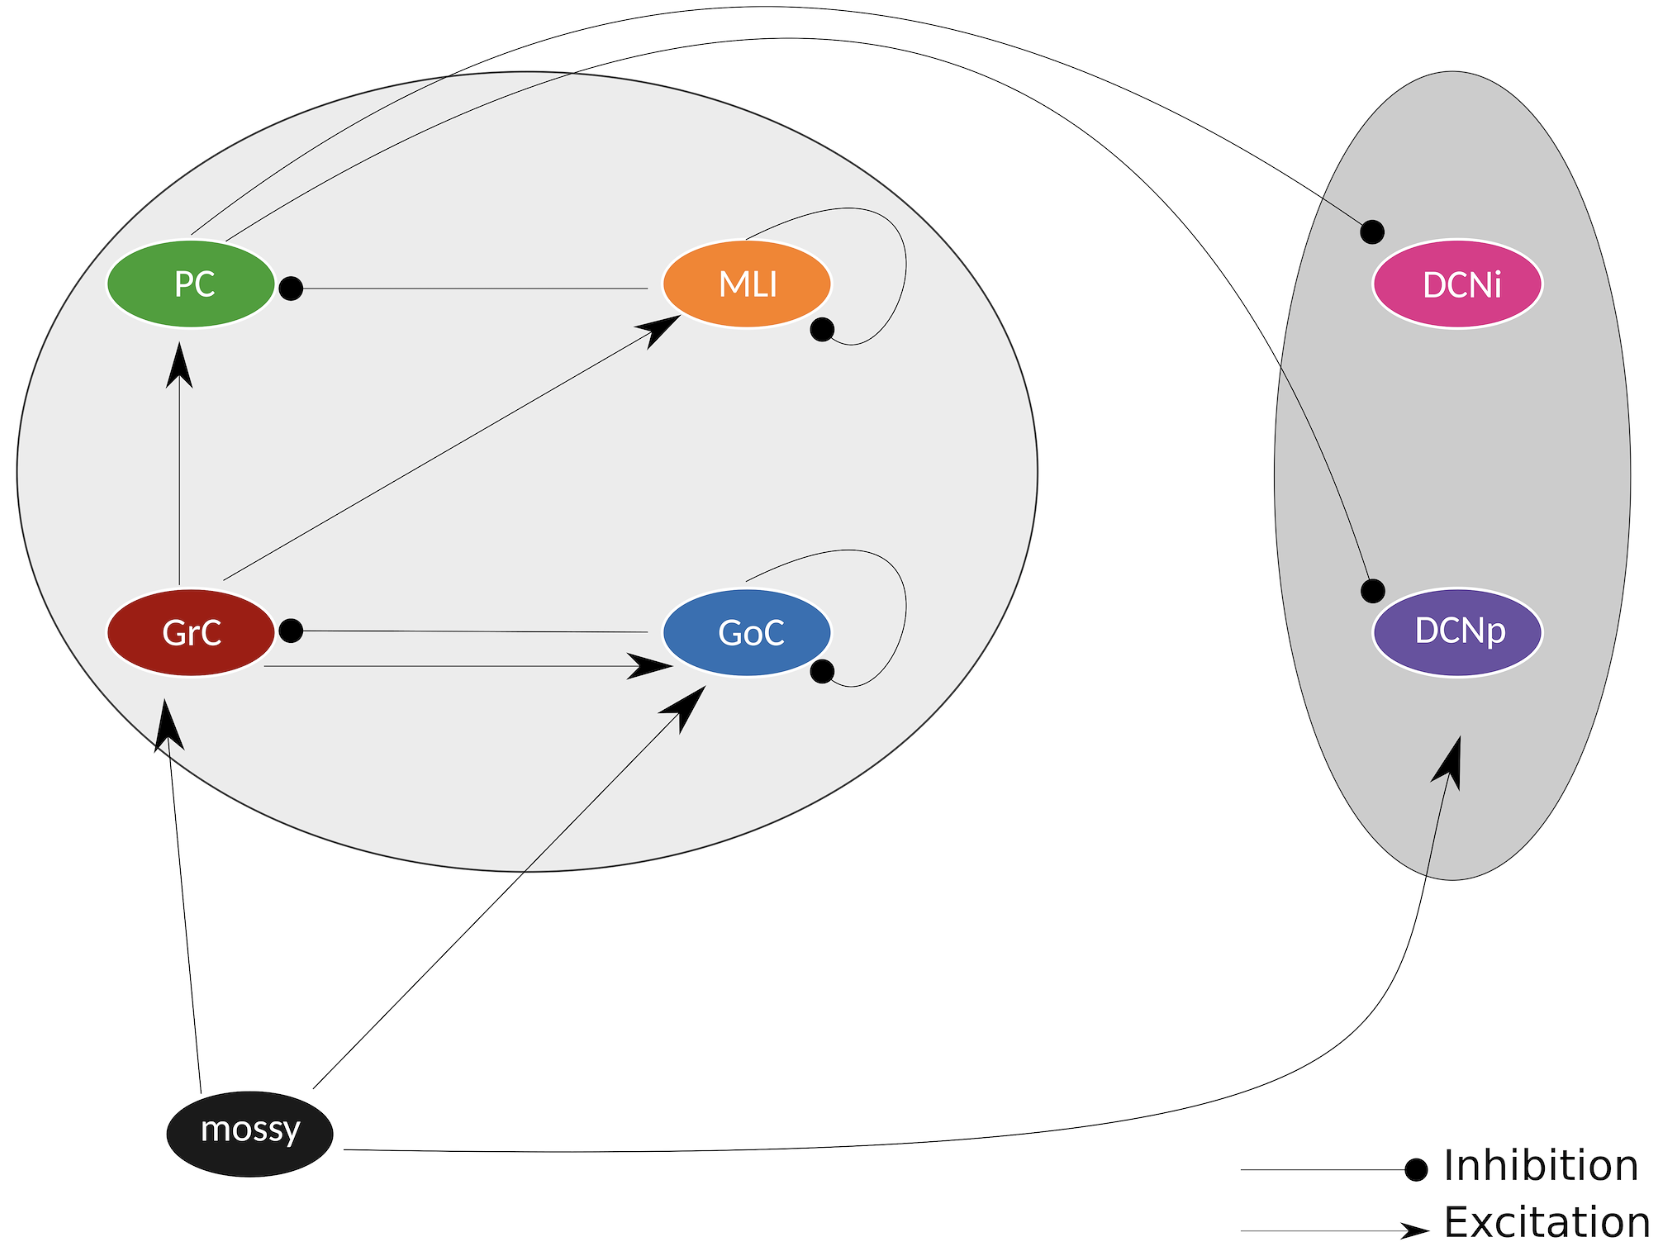

In [112]:
display(Image('figs/crbl_dcn.png'))

## Setting up the neuron models

In [113]:
from utils.Brian_function_helper import *
from utils.Plotting_helper import *
from utils.TF_functions import *

In [114]:
neuron_model = 'DCNi_cell' ### GABAergic - inhibitory ###
data_folder = './neuron_models'
idx = 0 # in this case only one model per cell type is provided
G_neuron_DCNi, params_DCNi = setting_EGLIF_simulation_Brian(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'))

# to have the neuron parameters in SI units
params_DCNi_SI = get_params_SI(params_DCNi[0][idx]['model'])

WARNING    The object 'neurongroup_6' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/content/drive/MyDrive/EITN_school_2026_MFM-main-2/Day5/utils/Brian_function_helper.py', line 163, in setting_EGLIF_simulation_Brian
    G_neuron = b2.NeuronGroup(N_cell, model=EGLIF_eqs, [brian2.core.base.unused_brian_object]


Imported data: ./neuron_models/DCNi_cell.json
neuron model: DCNi_cell


In [115]:
neuron_model = 'DCNp_cell' ### LargeGlut - excitatory ###
data_folder = './neuron_models'
idx = 0 # in this case only one model per cell type is provided
G_neuron_DCNp, params_DCNp = setting_EGLIF_simulation_Brian(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'))

# to have the neuron parameters in SI units
params_DCNp_SI = get_params_SI(params_DCNp[0][idx]['model'])

WARNING    The object 'neurongroup' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/content/drive/MyDrive/EITN_school_2026_MFM-main-2/Day5/utils/Brian_function_helper.py', line 163, in setting_EGLIF_simulation_Brian
    G_neuron = b2.NeuronGroup(N_cell, model=EGLIF_eqs, [brian2.core.base.unused_brian_object]


Imported data: ./neuron_models/DCNp_cell.json
neuron model: DCNp_cell


In [116]:
neuron_model = 'GrC_cell'
data_folder = './neuron_models'
idx = 0 # in this case only one model per cell type is provided
G_neuron_GrC, params_GrC = setting_EGLIF_simulation_Brian(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'))

# to have the neuron parameters in SI units
params_GrC_SI = get_params_SI(params_GrC[0][idx]['model'])

WARNING    The object 'neurongroup_1' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/content/drive/MyDrive/EITN_school_2026_MFM-main-2/Day5/utils/Brian_function_helper.py', line 163, in setting_EGLIF_simulation_Brian
    G_neuron = b2.NeuronGroup(N_cell, model=EGLIF_eqs, [brian2.core.base.unused_brian_object]


Imported data: ./neuron_models/GrC_cell.json
neuron model: GrC_cell


In [117]:
neuron_model = 'GoC_cell'
data_folder = './neuron_models'
idx = 0 # in this case only one model per cell type is provided
G_neuron_GoC, params_GoC = setting_EGLIF_simulation_Brian(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'))

# to have the neuron parameters in SI units
params_GoC_SI = get_params_SI(params_GoC[0][idx]['model'])

WARNING    The object 'neurongroup_2' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/content/drive/MyDrive/EITN_school_2026_MFM-main-2/Day5/utils/Brian_function_helper.py', line 163, in setting_EGLIF_simulation_Brian
    G_neuron = b2.NeuronGroup(N_cell, model=EGLIF_eqs, [brian2.core.base.unused_brian_object]


Imported data: ./neuron_models/GoC_cell.json
neuron model: GoC_cell


In [118]:
neuron_model = 'MLI_cell'
data_folder = './neuron_models'
idx = 0 # in this case only one model per cell type is provided
G_neuron_MLI, params_MLI = setting_EGLIF_simulation_Brian(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'))

# to have the neuron parameters in SI units
params_MLI_SI = get_params_SI(params_MLI[0][idx]['model'])

print(params_MLI_SI)

Imported data: ./neuron_models/MLI_cell.json
neuron model: MLI_cell


WARNING    The object 'neurongroup_3' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/content/drive/MyDrive/EITN_school_2026_MFM-main-2/Day5/utils/Brian_function_helper.py', line 163, in setting_EGLIF_simulation_Brian
    G_neuron = b2.NeuronGroup(N_cell, model=EGLIF_eqs, [brian2.core.base.unused_brian_object]


{'C_m': 1.46e-11, 'g_L': 1.6000000000000003e-09, 'E_L': -0.068, 'V_th': -0.053, 'V_reset': -0.078, 'V_spike': 0.02, 'delta_V': 0.0035, 'tau_V': 0.0011, 'lambda_0': 1.8, 't_ref': 0.00159, 'k_a': 2.025e-06, 'k_2': 1096.0, 'k_1': 1887.0, 'A_2': 5.8600000000000005e-12, 'A_1': 5.95e-12, 'I_e': 3.711e-12, 'E_e': 0.0, 'K_e': 609.9, 'T_e': 0.00064, 'Q_e': 1.4000000000000003e-10, 'E_i': -0.08, 'K_i': 14.15, 'T_i': 0.002, 'Q_i': 5.4945e-10}


In [119]:
neuron_model = 'PC_cell'
data_folder = './neuron_models'
idx = 0 # in this case only one model per cell type is provided
G_neuron_PC, params_PC = setting_EGLIF_simulation_Brian(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'))

# to have the neuron parameters in SI units
params_PC_SI = get_params_SI(params_PC[0][idx]['model'])

WARNING    The object 'neurongroup_4' is getting deleted, but was never included in a network. This probably means that you did not store the object reference in a variable, or that the variable was not used to construct the network.
The object was created here (most recent call only):
  File '/content/drive/MyDrive/EITN_school_2026_MFM-main-2/Day5/utils/Brian_function_helper.py', line 163, in setting_EGLIF_simulation_Brian
    G_neuron = b2.NeuronGroup(N_cell, model=EGLIF_eqs, [brian2.core.base.unused_brian_object]


Imported data: ./neuron_models/PC_cell.json
neuron model: PC_cell


In [120]:
with open('./fitting/DCNi_TF_params.json', 'r') as f:
            data_DCNi = json.load(f)

with open('./fitting/DCNp_TF_params.json', 'r') as f:
            data_DCNp = json.load(f)

In [121]:
# Selection of which P-config we want to use.
DCNi_idx = 1
DCNp_idx = 0

In [122]:
with open('./fitting/GrC_TF_params.json', 'r') as f:
            data_GrC = json.load(f)

with open('./fitting/GoC_TF_params.json', 'r') as f:
            data_GoC = json.load(f)

with open('./fitting/MLI_TF_params.json', 'r') as f:
           data_MLI = json.load(f)

with open('./fitting/PC_TF_params.json', 'r') as f:
            data_PC = json.load(f)

In [123]:
# Only one configuration (i.e, one value of alpha)
# Not univocal solution for the fitting --> different alpha values provides comparabe fitting.
idx_GrC = 2
idx_GoC = 1
idx_MLI = 4
idx_PC = 0

In [124]:
P0_i, P1_i, P2_i, P3_i, P4_i = data_DCNi[DCNi_idx]['P0'], data_DCNi[DCNi_idx]['P1'], data_DCNi[DCNi_idx]['P2'], data_DCNi[DCNi_idx]['P3'], data_DCNi[DCNi_idx]['P4']
alpha_DCNi = data_DCNi[DCNi_idx]['alpha']

P0_p, P1_p, P2_p, P3_p, P4_p =  data_DCNp[DCNp_idx]['P0'], data_DCNp[DCNp_idx]['P1'], data_DCNp[DCNp_idx]['P2'], data_DCNp[DCNp_idx]['P3'], data_DCNp[DCNp_idx]['P4']
alpha_DCNp = data_DCNp[DCNp_idx]['alpha']

In [125]:
P0_grc, P1_grc, P2_grc, P3_grc, P4_grc = data_GrC[idx_GrC]['P0'], data_GrC[idx_GrC]['P1'], data_GrC[idx_GrC]['P2'], data_GrC[idx_GrC]['P3'], data_GrC[idx_GrC]['P4']
alpha_GrC = data_GrC[idx_GrC]['alpha']

P0_goc, P1_goc, P2_goc, P3_goc, P4_goc = data_GoC[idx_GoC]['P0'], data_GoC[idx_GoC]['P1'], data_GoC[idx_GoC]['P2'], data_GoC[idx_GoC]['P3'], data_GoC[idx_GoC]['P4']
alpha_GoC = data_GoC[idx_GoC]['alpha']

P0_mli, P1_mli, P2_mli, P3_mli, P4_mli = data_MLI[idx_MLI]['P0'], data_MLI[idx_MLI]['P1'], data_MLI[idx_MLI]['P2'], data_MLI[idx_MLI]['P3'], data_MLI[idx_MLI]['P4']
alpha_MLI = data_MLI[idx_MLI]['alpha']

P0_pc, P1_pc, P2_pc, P3_pc, P4_pc = data_PC[idx_PC]['P0'], data_PC[idx_PC]['P1'], data_PC[idx_PC]['P2'], data_PC[idx_PC]['P3'], data_PC[idx_PC]['P4']
alpha_PC = data_PC[idx_PC]['alpha']

In [126]:
print(P0_pc)

-0.0577421071


In [127]:
alpha_PC = 4.5

In [128]:
def TF_dcni(fe, fi, w):
    return TF_template_eglif(
        P0_i, P1_i, P2_i, P3_i, P4_i,
        fe=fe,
        fi=fi,
        adapt= 0.0,
        alpha = alpha_DCNi,
        params_SI = params_DCNi_SI
    )

## TO BE CHECKED: fe_i form grc??
def TF_dcnp(fe_i, fe_m, fi, w):
    return TF_template_eglif_dcnp(
        P0_p, P1_p, P2_p, P3_p, P4_p,
        fe_i = fe_i,
        fe_m = fe_m,
        fi = fi,
        adapt=0.0,
        alpha = alpha_DCNp,
        params_SI = params_DCNp_SI
    )

In [129]:
def TF_GrC(fe, fi, w):
    return TF_template_eglif(
        P0_grc, P1_grc, P2_grc, P3_grc, P4_grc,
        fe=fe,
        fi=fi,
        adapt= 0.0,
        alpha = alpha_GrC,
        params_SI = params_GrC_SI
    )


def TF_GoC(fe_i, fe_m, fi, w):
    return TF_template_eglif_dcnp(
        P0_goc, P1_goc, P2_goc, P3_goc, P4_goc,
        fe_i = fe_i,
        fe_m = fe_m,
        fi = fi,
        adapt=0.0,
        alpha = alpha_GoC,
        params_SI = params_GoC_SI
    )

def TF_MLI(fe, fi, w):
    return TF_template_eglif(
        P0_mli, P1_mli, P2_mli, P3_mli, P4_mli,
        fe=fe,
        fi=fi,
        adapt= 0.0,
        alpha = alpha_MLI,
        params_SI = params_MLI_SI
    )

def TF_PC(fe, fi, w):
    return TF_template_eglif(
        P0_pc, P1_pc, P2_pc, P3_pc, P4_pc,
        fe=fe,
        fi=fi,
        adapt= 0.0,
        alpha = alpha_PC,
        params_SI = params_PC_SI
    )

## Mean field simulation

In [130]:
#mean field time constant
T = 3.5e-3
#T = 1e-3

#initial condition
v_dcni0, v_dcnp0 = 0.5, 20

v_grc0 = 0.5
v_goc0 = 5
v_mli0 = 15
v_pc0 = 80 #zmin

#simulators parameters
dt = 1e-4
time = np.arange(0, 3 + dt, dt)
h = 1e-4

## Construction of MFM Network

In [131]:
def solve_MF_CRCTX_DCN_firstorder(TF_GrC, TF_GoC, TF_MLI, TF_PC, TF_DCNi, TF_DCNp, time, h, T,
                                   v_grc0, v_goc0, v_mli0, v_pc0, v_dcni0, v_dcnp0,
                                   driving_input_mossy, stim_dbs = 0):
    #the excitation (driving input) arrives from mossy fibers - to Granule and Golgi cells

    h = time[1] - time[0]
    v_grc = np.zeros_like(time)
    v_goc = np.zeros_like(time)
    v_mli = np.zeros_like(time)
    v_pc = np.zeros_like(time)

    v_dcni = np.zeros_like(time)
    v_dcnp = np.zeros_like(time)


    v_grc[0], v_goc[0], v_mli[0], v_pc[0] = v_grc0, v_goc0, v_mli0, v_pc0
    v_dcni[0], v_dcnp[0] = v_dcni0, v_dcnp0

    w = np.zeros(len(time)) # there is no adaptation

    for t in range(1, len(time)):
        ## MFM CRBL CTX
        TF_GrC_MF = TF_GrC(driving_input_mossy[t-1], v_goc[t-1], w[t-1])          #
        TF_GoC_MF  = TF_GoC(v_grc[t-1], driving_input_mossy[t-1], v_goc[t-1], w[t-1])#same signature of dcnp = same order of input elements
        TF_MLI_MF = TF_MLI(v_grc[t-1], v_mli[t-1], w[t-1])
        TF_PC_MF = TF_PC(v_grc[t-1], v_mli[t-1], w[t-1])
        ## TFDCN
        TF_DCNi_MF = TF_DCNi(0+stim_dbs[t-1], v_pc[t-1], w[t-1])
        TF_DCNp_MF = TF_DCNp(0, driving_input_mossy[t-1] + stim_dbs[t-1], v_pc[t-1], w[t-1])

        v_grc[t]  = v_grc[t-1] + (h / T) * (TF_GrC_MF - v_grc[t-1])
        v_goc[t]   = v_goc[t-1]  + (h / T) * (TF_GoC_MF  - v_goc[t-1])
        v_mli[t]   = v_mli[t-1]  + (h / T) * (TF_MLI_MF  - v_mli[t-1])
        v_pc[t]   = v_pc[t-1]  + (h / T) * (TF_PC_MF  - v_pc[t-1])

        v_dcni[t]   = v_dcni[t-1]  + (h / T) * (TF_DCNi_MF  - v_dcni[t-1])
        v_dcnp[t]   = v_dcnp[t-1]  + (h / T) * (TF_DCNp_MF  - v_dcnp[t-1])



    return v_grc, v_goc, v_mli, v_pc, v_dcni, v_dcnp

In [132]:
def plot_my_mfm(v_dcni, v_dcnp, v_pc, v_mli, v_goc, v_grc, driving_input, name_sim = 'test'):

    plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
    "lines.linewidth": 2.5
    })

    fig, axs = plt.subplots(
        7, 1,
        figsize=(10, 10),
        sharex=True,
        constrained_layout=True
    )

    signals = [
        (v_dcni, 'DCNi', 'hotpink'),
        (v_dcnp, 'DCNp', 'purple'),
        (v_pc, 'PC', 'green'),
        (v_mli, 'MLI', 'orange'),
        (v_goc, 'GoC', 'blue'),
        (v_grc, 'GrC', 'red'),
        (driving_input, 'mfs', 'black'),
        ]

    for ax, (signal, title, color) in zip(axs, signals):
        ax.plot(time, signal, color=color)
        #ax.set_ylabel('[Hz]')
        ax.set_title(title)
        ax.set_ylim([0, np.max(signal)+0.25*np.max(signal)])
        ax.grid(alpha=0.3)

    axs[-1].set_xlabel('Time [s]')
    axs[2].set_ylabel('Firing rate [Hz]')

    # Salvataggio nella working directory
    filename = os.path.join(os.getcwd(), "NET_CRCTX_DCN"+name_sim+".pdf")
    #plt.savefig(filename, dpi=300, bbox_inches='tight')

    print(f"Figure saved in:\n{filename}")

    plt.show()

In [133]:
## Intended to be used for DBS stimulation in DCN -- Clinical practice in Dystonia and Ataxia
input_dbs = np.ones_like(time)*0

In [134]:
driving_input_mossy = np.random.randn(len(time))*10

Figure saved in:
/content/drive/MyDrive/EITN_school_2026_MFM-main-2/Day5/NET_CRCTX_DCNrandom.pdf


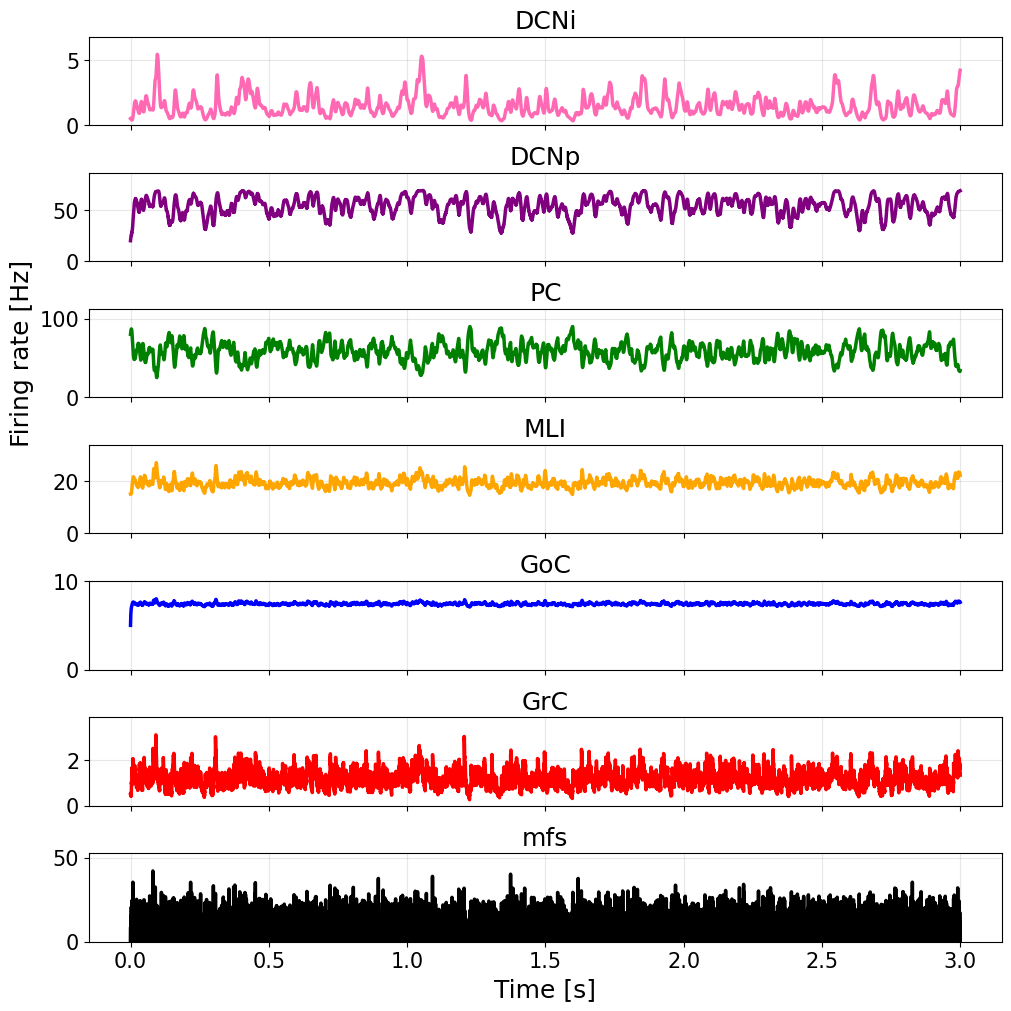

In [135]:
v_grc, v_goc, v_mli, v_pc, v_dcni, v_dcnp = solve_MF_CRCTX_DCN_firstorder(TF_GrC, TF_GoC, TF_MLI, TF_PC, TF_dcni, TF_dcnp,
                                                                          time, h, T,
                                                                          v_grc0, v_goc0, v_mli0, v_pc0, v_dcni0, v_dcnp0,
                                                                          driving_input_mossy, stim_dbs=input_dbs*0)

plot_my_mfm(v_dcni, v_dcnp, v_pc, v_mli, v_goc, v_grc, driving_input_mossy, name_sim = 'random')

## Example 1
Cortical like input mimicks an oscillatory input coming from the cortex and driven by the mossy fibers

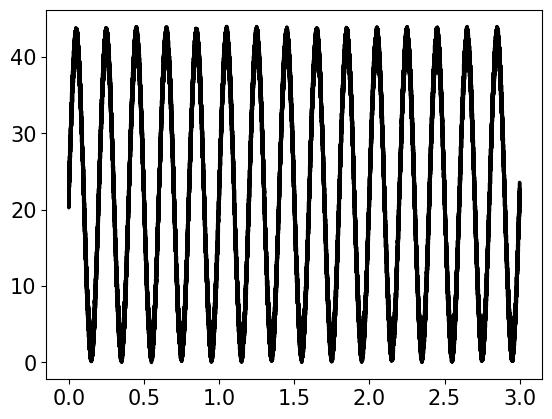

In [136]:
## Cortical Like input
back_noise = np.random.rand(len(time))*4
A = 20 #center of the signal
freq = 5
driving_input_mossy_cortical_like = A + A * np.sin(2*np.pi *freq * time) + back_noise
plt.plot(time, driving_input_mossy_cortical_like, 'black')

Figure saved in:
/content/drive/MyDrive/EITN_school_2026_MFM-main-2/Day5/NET_CRCTX_DCNsinusoidal.pdf


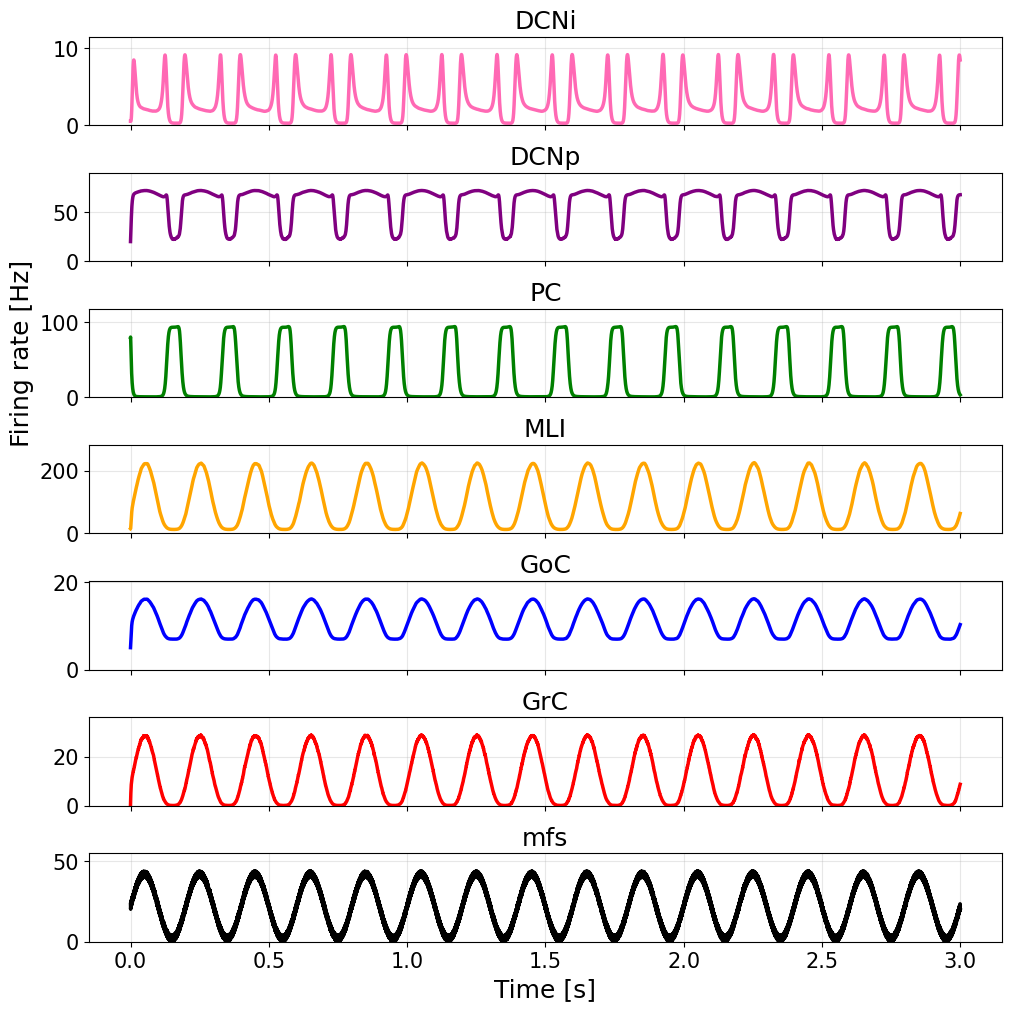

In [137]:
del v_grc, v_goc, v_mli, v_pc, v_dcni, v_dcnp

v_grc, v_goc, v_mli, v_pc, v_dcni, v_dcnp = solve_MF_CRCTX_DCN_firstorder(TF_GrC, TF_GoC, TF_MLI, TF_PC, TF_dcni, TF_dcnp,
                                                                          time, h, T,
                                                                          v_grc0, v_goc0, v_mli0, v_pc0, v_dcni0, v_dcnp0,
                                                                          driving_input_mossy_cortical_like, stim_dbs=input_dbs*0)

plot_my_mfm(v_dcni, v_dcnp, v_pc, v_mli, v_goc, v_grc, driving_input_mossy_cortical_like, name_sim = 'sinusoidal')

## Example 2

Stimulus like input: gaussian input overlayed to a sinusoid

WARNING    /tmp/ipykernel_901/665623924.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(); plt.xlabel('time'); plt.ylabel('input')
 [py.warnings]
  plt.legend(); plt.xlabel('time'); plt.ylabel('input')



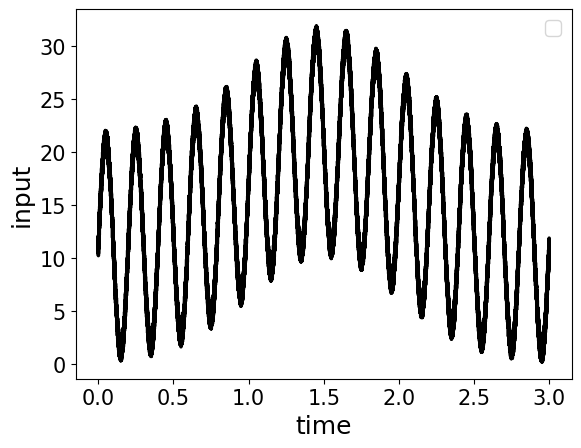

In [138]:
## Gaussian pulse
G_amp = 10    # amplitude (Hz)
t0 = 1.5
sigma = 0.5  # width in seconds; FWHM ≈ 2.355*sigma
gauss = G_amp * np.exp(-(time - t0)**2 / (2 * sigma**2))

driving_input_mossy_stimulus_like = driving_input_mossy_cortical_like*0.5 + gauss

plt.plot(time, driving_input_mossy_stimulus_like, 'black')
plt.legend(); plt.xlabel('time'); plt.ylabel('input')
plt.show()

Figure saved in:
/content/drive/MyDrive/EITN_school_2026_MFM-main-2/Day5/NET_CRCTX_DCNgaussian.pdf


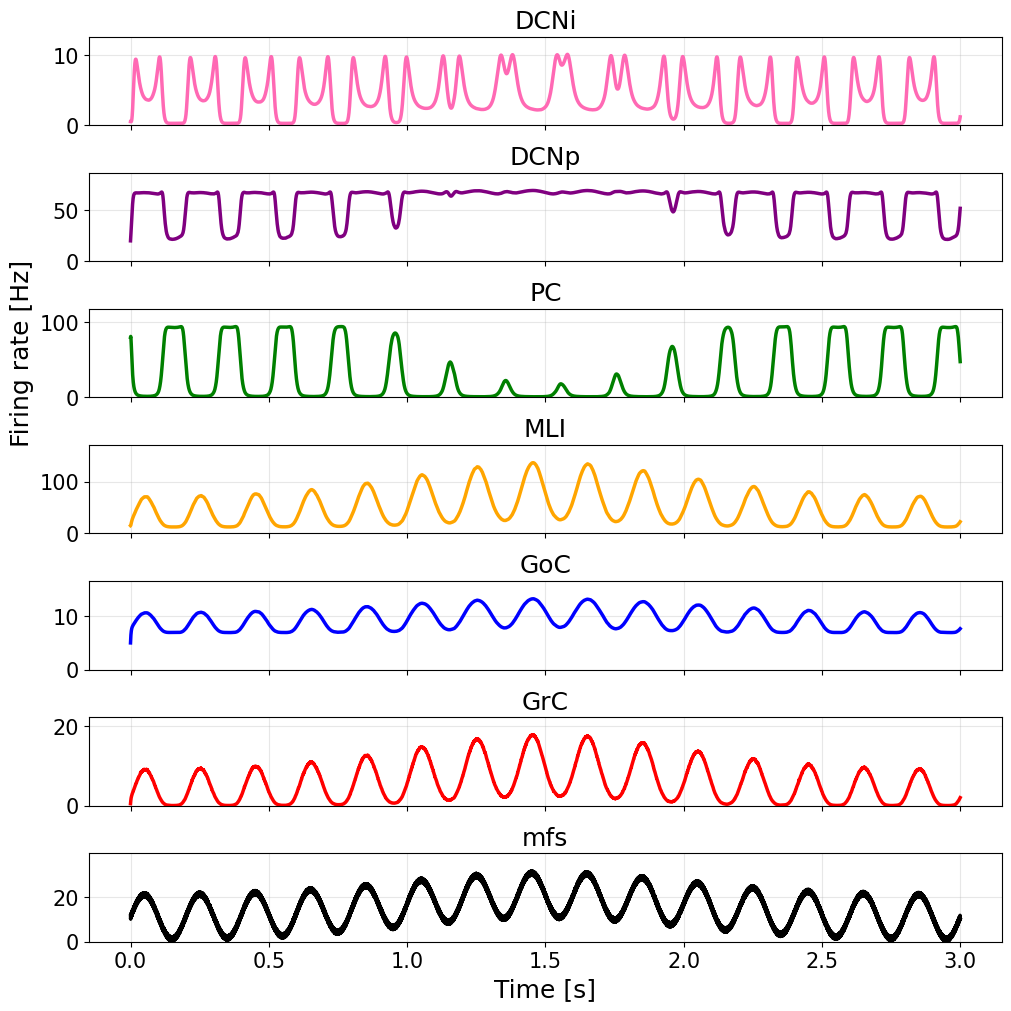

In [139]:
del v_grc, v_goc, v_mli, v_pc, v_dcni, v_dcnp

v_grc, v_goc, v_mli, v_pc, v_dcni, v_dcnp = solve_MF_CRCTX_DCN_firstorder(TF_GrC, TF_GoC, TF_MLI, TF_PC, TF_dcni, TF_dcnp,
                                                                          time, h, T,
                                                                          v_grc0, v_goc0, v_mli0, v_pc0, v_dcni0, v_dcnp0,
                                                                          driving_input_mossy_stimulus_like, stim_dbs=input_dbs*0)

plot_my_mfm(v_dcni, v_dcnp, v_pc, v_mli, v_goc, v_grc, driving_input_mossy_stimulus_like, name_sim = 'gaussian')